# S11-3 日次カーブモニタリングダッシュボード（Capstone最終）

## 学習目標

- 実務者が毎朝見る「1画面のモニタリング（monitoring）」を、日次パー利回り
  パネルから自作し、運用できる
- カーブ推移・KRD（key rate duration）・rich/cheap・キャリー/ロール・
  バタフライシグナル（signal）・アラート（alert）を1枚の図に載せる情報設計
  （何を載せ、何を捨てるか）を、判断基準とともに説明できる
- アラート閾値（alert threshold）を勘ではなく**過去分布の分位点**で決め、
  誤報率（false alarm rate）と検出率のトレードオフを定量化できる
- 60営業日パネルで日次ダッシュボードを再現し、最新営業日の「今朝の画面」を
  1枚に組める

S11 は Capstone です。S2 のカーブ構築、S3 の KRD、S9 の rich/cheap・
キャリー/ロール・バタフライを、毎朝1回まわす運用画面へ束ねます。単発の
計算ではなく、「見るべきものが一目で揃い、異常だけが目に飛び込む画面」を
設計することが主題です。

## 実務での位置づけ（ファンドはどう稼ぐか）

この日次ダッシュボードは、相対価値（RV）デスクのトレーダーやリスク管理者が毎朝いちばん最初に開く「1画面のモニタリング」に対応します。RV ファンドの稼ぎは、証券間の価格のゆがみが将来収束・発散する方向に賭けて得るキャリー（利ざや）です。どのテナーがカーブ対比で安いか（rich/cheap）、時間だけで稼げる分（キャリー／ロール）はどこが厚いか、ベリー対ウイングのバタフライは平常水準からどれだけ外れているか——こうした「今日エントリーする価値のあるゆがみ」を毎朝素早く拾えるかどうかが、そのままアルファの源泉になります。カーブ推移・KRD・rich/cheap・キャリー/ロール・バタフライシグナルを1枚に束ねる本 notebook は、朝の意思決定を数秒で下すための土台です。

この画面は稼ぐためだけでなく、損失を避けるためにも働きます。自分の持ち高の金利感応度（KRD）がどのテナーに寄っているかを毎朝確認することは、意図せぬデュレーションの偏りやヘッジ崩れを早期に捉えるリスク管理そのものです。アラート閾値を勘ではなく過去分布の分位点で決め、誤報率と検出率のトレードオフを定量化する設計は、「平常は静かに、異常だけが目に飛び込む」画面を作るための核心です。閾値が緩すぎれば本当の異常が日々のノイズに埋もれ、厳しすぎれば警報が鳴りやまず誰も見なくなります。逸脱を早く捉えられれば、ポジションが痛む前に手仕舞い・ヘッジ調整に動けます。

就職の観点では、ヘッジファンドの RV リサーチ（S9・S3・S2 が効く）やリスク管理職に対して、「単発の計算」ではなく「毎朝まわる運用フローを設計・実装できる」ことを示す成果物になります。何を1画面に載せ、何を捨てるかという情報設計の判断を、判断基準とともに言語化できることは、実際にデスクで日次の運用に乗せられる人材であることの証拠になります。


## 理論

### モニタリングとは何か

モニタリング（monitoring）とは、市場・ポジション・モデル出力の状態を定時に
観測し、平常からの逸脱を早く捉えるための継続的な監視です。相対価値（RV）
トレーダーにとっての朝の画面は、次の問いに数秒で答えられることが要件です。

- カーブは昨日から、水準・傾き・曲率のどこがどれだけ動いたか
- 自分の持ち高（ポジション）の金利感応度（KRD）はどのテナーに寄っているか
- カーブ対比で安い／高いテナー（rich/cheap）はどこか
- 時間だけで稼げる分（キャリー／ロール）はどのテナーが厚いか
- ベリー対ウイングのバタフライは、平常水準からどれだけ外れているか
- そのうち、人が今すぐ見るべき逸脱（アラート）はあるか

### 情報設計：1画面に何を載せ、何を捨てるか

朝の画面の敵は「情報の出しすぎ」です。全テナー・全指標・全履歴を並べると、
かえって異常が埋もれます。設計原則を3つに絞ります。

1. **1指標1目的**：各パネルは「1つの問い」に答える。カーブ推移は水準・
   形状の把握、KRD は自分の感応度、rich/cheap は個別テナーの割高割安、と
   役割を1つに固定し、1枚に混載しません。
2. **平常は静か、異常は目立つ**：正常時に画面が騒がしいと、本当の異常が
   埋もれます。平常時の変動は淡い線で背景化し、閾値超えだけを強い色で前に
   出します。捨てるのは「毎日ほぼ同じで判断を変えない情報」です。
3. **相対化して載せる**：絶対水準（33bp のバタフライ等）は、それ自体では
   高いか低いか判断できません。過去分布に対する位置（$z$ スコアや分位点）に
   直してから載せると、テナーや指標をまたいで一目で比較できます。

載せるものは「見れば判断（発注・見送り）が変わる情報」に限り、載せないものは
「参照はできるが朝の意思決定を変えない情報」（明細・全履歴）です。後者は
ドリルダウン（別画面）へ回します。

### 各パネルの定義

#### カーブ推移

当日のパー利回り曲線と、数営業日前の曲線を重ねます。水準シフト・スティープ
化・フラット化・曲率変化が、線の重なり方から一目で読めます。

#### KRD（キーレートデュレーション, key rate duration）

ポジションの価格が、特定テナーのゼロレートを 1bp 動かしたときにどれだけ動くか
です。テナー $i$ を幅 $w$ で三角バンプ（bump）した価格を $P_i^{\pm}$ として、

$$ \text{KRD}_i = -\frac{P_i^{+} - P_i^{-}}{2\,\Delta y\,P_0} $$

で近似します（$\Delta y$ はバンプ幅）。KRD の合計は実効デュレーションに一致し、
「自分のリスクがどのテナーに乗っているか」を示します。

#### rich/cheap

その日の流動性ベンチマーク（例：0.5/2/5/10/30年）に平滑カーブ（NSS）を
フィットし、各テナーの実測利回りとの残差 $r_i = y_i - \hat{y}(\tau_i)$ を
bp で測ります。$r_i>0$ は利回りが高い＝価格が安い＝cheap、$r_i<0$ は rich
です（符号の約束は S9-1 と同一）。残差を各テナーの時系列で基準化した $z$ で
相対比較します。

#### キャリー／ロール

カーブが不変なら、時間の経過だけで確定するリターンです。満期 $T$ のゼロを
保有期間 $h$ 持つときのキャリー＋ロールは、スポットとフォワードの差

$$ \text{carry+roll}(T) \approx \big(z(T) - f(h,T)\big) $$

で近似できます（$f(h,T)$ は区間 $[h,T]$ の連続複利フォワード, S9-3）。
順イールドでフォワードがスポットより低いほど、正のキャリー＋ロールです。

#### バタフライシグナル

ベリー（中期）対ウイング（短期・長期）の相対価値です。2-5-10 のバタフライを

$$ \text{fly} = 2\,y(5) - y(2) - y(10) $$

で定義し、時系列で $z$ スコア化します。$z$ が大きいほどベリーが割安（ウイング
対比で利回りが高い）で、平均回帰を狙う RV の起点になります。

### アラート設計：閾値を統計的根拠で決める

アラート（alert）とは、監視対象が定めた閾値を超えたときに人へ知らせる仕組み
です。設計の中心はアラート閾値（alert threshold）の決め方です。勘で「$z>2$」
と置くのではなく、**過去分布の分位点**で決めます。指標 $S$ の過去 $T$ 日の
分布に対し、両側の分位点しきい値を

$$ \theta_q = \text{Quantile}_{q}\big(\,|S_t|\,;\ t=1,\dots,T\big) $$

と置けば、過去において $|S_t|>\theta_q$ となる割合は定義上 $1-q$ です。
つまり分位点 $q$ は、そのまま**平常時にアラートが鳴る割合（＝誤報率の目安）**
を決めるノブになります。$q=0.95$ なら平常時の発火はおよそ 5% です。

誤報率（false alarm rate, 空振り率）とは、本当は行動不要なのにアラートが
鳴った割合です。閾値を下げれば見逃しは減りますが誤報が増え、上げれば誤報は
減りますが検出が遅れます。これは感度（検出率）と誤報率のトレードオフで、
分位点設計は「誤報率の目標値を先に決めて、それを満たす閾値を分布から逆算する」
という運用可能な形にこの綱引きを載せます。

### ポイントインタイム性

各営業日の閾値・$z$ スコアは、**その日までの履歴だけ**から作ります（先読み
禁止, S2-5 と同じ原則）。将来を含む全期間統計で当日を基準化すると、実運用
では得られない情報でアラートを「後知恵で正解」させてしまいます。

**数値例**：代表ポジション（$P_0=100$）の10年ゼロを 1bp（$\Delta y=10^{-4}$）三角バンプし、$P_i^{+}=99.92$、$P_i^{-}=100.08$ が得られたとすると、$\text{KRD}_i = -\dfrac{99.92-100.08}{2\cdot10^{-4}\cdot100} = 8.0$ 年です。この銘柄のリスクが当該テナーに約 8 年分乗っていることを示します。


**数値例**：$y(2)=0.60\%$、$y(5)=1.15\%$、$y(10)=1.60\%$ のとき、$\text{fly} = 2\cdot1.15\% - 0.60\% - 1.60\% = +0.10\%$、すなわち $+10$ bp です。正なのでベリー（5年）がウイング対比で割安（利回りが高い）で、平均回帰を狙う起点になります。


**数値例**：過去 $T=60$ 日のバタフライ $z$ に対し $q=0.95$ で閾値を置くと、平常時にアラートが鳴る割合は定義上 $1-q=5\%$、日数にして $0.05\times60=3$ 日程度です。誤報率の目標を先に $5\%$ と決め、それを満たす閾値を過去分布から逆算する形になります。


## スクラッチ実装

上の各パネルを、単体で使える純粋関数に落とします。ダッシュボードは「計算」と
「描画」を分け、`compute_dashboard` が全パネルの数値を辞書にまとめ、
`render_dashboard` がそれを1枚の図へ組みます。この分離により、同じ計算を
notebook と Streamlit アプリ（`app/dashboard.py`）の双方から使えます。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `load_par_panel(path)` | CSVパス | `DataFrame`（行=日付, 列=テナー） | 縦持ちパネルを横持ちへ整形 |
| `build_zero_panel(panel, freq)` | パネル, 頻度 | ゼロレート `DataFrame` | 全日をブートストラップしてゼロ曲面を作る |
| `price_bond_on_curve(curve, coupon, maturity, freq)` | カーブ, クーポン, 満期, 頻度 | 価格（`float`） | カーブ割引で固定利付債を評価 |
| `key_rate_durations(curve, coupon, maturity, keys, freq)` | カーブ, クーポン, 満期, キーテナー, 頻度 | `Series`（KRD） | 三角バンプで KRD を測る |
| `richcheap_residuals(panel, bench, lam_grid)` | パネル, ベンチマークテナー, λ格子 | 残差 `DataFrame`（bp） | ベンチ対比の rich/cheap 残差 |
| `zscore_panel(df, upto)` | 表, 当日 | `DataFrame` | 当日までの履歴で列ごとに $z$ 化（先読み無し） |
| `carry_roll(curve, tenors, horizon)` | カーブ, テナー, 保有期間 | `Series`（bp） | スポット−フォワードでキャリー＋ロール |
| `butterfly_series(panel, wings, belly)` | パネル, ウイング, ベリー | `Series`（bp） | 2-5-10 等のバタフライ時系列 |
| `alert_threshold(series, q)` | 系列, 分位点 | 閾値（`float`） | 過去分布の分位点でしきい値を決める |
| `evaluate_alerts(state, q)` | 計算結果, 分位点 | アラート `list` | 当日の指標を閾値と突き合わせて発火判定 |
| `backtest_false_alarm(series, q)` | 系列, 分位点 | 誤報率（`float`） | 分位点閾値の平常時発火率を測る |
| `compute_dashboard(panel, asof, freq, ...)` | パネル, 基準日, 頻度 ほか | `dict`（全パネルの数値） | 画面に載せる数値を一括計算 |
| `render_dashboard(state)` | 計算結果 | `Figure` | 数値を1枚の図に組む |

In [1]:
import os

os.environ.setdefault("MPLBACKEND", "Agg")

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from bondlab.curve import bootstrap_par, fit_nss, nss, DiscountCurve
from bondlab.analytics import bump_curve

# 再現性のため乱数種を固定します（本文は決定論的。演習・検証のショック注入で使用）。
np.random.seed(0)

BP = 1e4  # 1 = 10000bp。利回り差を bp 表示するときに掛けます。

# rich/cheap のフェア値を張る流動性ベンチマークテナー（オンザラン想定）。
BENCH_TENORS = (0.5, 2.0, 5.0, 10.0, 30.0)
# 2-5-10 バタフライの (左ウイング, ベリー, 右ウイング)。
FLY_LEGS = (2.0, 5.0, 10.0)
# KRD を測るキーテナーと、代表ポジションの満期。
KEY_TENORS = (2.0, 5.0, 10.0, 30.0)
HOLD_HORIZON = 0.25  # キャリー／ロールの保有期間（年, 3か月）。

### データ読み込みとゼロ曲面

パネルは縦持ち（`date, tenor, par_yield`）で配布されています。横持ちに直し、
各日をブートストラップして連続複利ゼロレートの曲面を作ります。テナーは
S2-5 と同様に「クーポン払込ノード」とみなして扱います（非等間隔の警告は
想定内なので抑制します）。

In [2]:
def load_par_panel(path) -> pd.DataFrame:
    """日次パー利回りパネル CSV を (行=日付, 列=テナー) の DataFrame に整形します。"""
    raw = pd.read_csv(path)
    expected = {"date", "tenor", "par_yield"}
    if set(raw.columns) != expected:
        raise ValueError(f"想定外の列: {list(raw.columns)}（期待 {sorted(expected)}）")
    raw["date"] = pd.to_datetime(raw["date"])
    panel = raw.pivot(index="date", columns="tenor", values="par_yield")
    return panel.sort_index().sort_index(axis=1)


def _curve_from_row(tenors, par_rates, freq=1) -> DiscountCurve:
    """1日分のパー利回りから割引カーブを作ります（非等間隔の警告は抑制）。"""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return bootstrap_par(np.asarray(tenors, float), np.asarray(par_rates, float),
                             frequency=freq)


def build_zero_panel(panel, freq=1) -> pd.DataFrame:
    """全営業日をブートストラップし、連続複利ゼロレートの (日付×テナー) 表を返します。"""
    tenors = np.asarray(panel.columns, dtype=float)
    rows = {}
    for d, row in panel.iterrows():
        curve = _curve_from_row(tenors, row.to_numpy(float), freq)
        rows[d] = curve.zero_rate(tenors)
    out = pd.DataFrame(rows).T
    out.columns = tenors
    out.index.name = "date"
    return out


DATA_PATH = Path("data") / "samples" / "synthetic_ust_par_panel.csv"
panel = load_par_panel(DATA_PATH)
TENORS = np.asarray(panel.columns, dtype=float)
zero_panel = build_zero_panel(panel, freq=1)

print("パネル形状 (日数, テナー数):", panel.shape)
print("期間:", panel.index.min().date(), "〜", panel.index.max().date())
print("テナー(年):", [float(t) for t in TENORS])
print("欠損セル数:", int(panel.isna().sum().sum()))
print("\n最新営業日のパー利回り(%):")
print((panel.iloc[-1] * 100).round(3).to_dict())

パネル形状 (日数, テナー数): (60, 9)
期間: 2026-01-02 〜 2026-03-26
テナー(年): [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
欠損セル数: 0

最新営業日のパー利回り(%):
{0.5: 2.778, 1.0: 3.041, 2.0: 3.44, 3.0: 3.714, 5.0: 4.036, 7.0: 4.195, 10.0: 4.302, 20.0: 4.381, 30.0: 4.395}


### KRD：代表ポジションの金利感応度

代表ポジションとして、最新カーブでほぼパーになる 10年・年1回利付債を1単位
持つとします。カーブ割引で価格を求め、キーテナーを三角バンプした価格差から
KRD を測ります。KRD の合計は実効デュレーションに一致するはずです。

In [3]:
def price_bond_on_curve(curve, coupon, maturity, freq=1):
    """カーブの割引係数で固定利付債（額面1）を評価します。"""
    n = int(round(maturity * freq))
    times = np.arange(1, n + 1) / freq
    cfs = np.full(n, coupon / freq)
    cfs[-1] += 1.0
    return float(np.sum(cfs * curve.discount(times)))


def key_rate_durations(curve, coupon, maturity, keys=KEY_TENORS, freq=1,
                       bump=1e-4, width=None):
    """キーテナーごとに三角バンプで KRD を測り、Series（キーテナー→KRD）を返します。"""
    keys = np.asarray(keys, dtype=float)
    if width is None:
        width = float(np.median(np.diff(keys)))  # 隣接キー間隔を三角の幅にします。
    p0 = price_bond_on_curve(curve, coupon, maturity, freq)
    krd = {}
    for k in keys:
        up = bump_curve(curve, k, bump, width=width)
        dn = bump_curve(curve, k, -bump, width=width)
        p_up = price_bond_on_curve(up, coupon, maturity, freq)
        p_dn = price_bond_on_curve(dn, coupon, maturity, freq)
        krd[k] = -(p_up - p_dn) / (2.0 * bump * p0)
    return pd.Series(krd, name="KRD")

### rich/cheap：ベンチマーク対比の残差

流動性ベンチマークだけに NSS をフィットして「その日のフェアカーブ」を張り、
全テナーの実測利回りとの残差を bp で測ります。ベンチマーク自身は残差ほぼゼロ、
ベンチ外テナー（1/3/7/20年）の乖離が rich/cheap のシグナルになります。

In [4]:
def richcheap_residuals(panel, bench=BENCH_TENORS, lam_grid=None):
    """ベンチマークに NSS をフィットし、全テナーの残差(bp)の (日付×テナー) 表を返します。"""
    if lam_grid is None:
        lam_grid = np.linspace(0.8, 8.0, 8)
    tenors = np.asarray(panel.columns, dtype=float)
    bidx = [list(tenors).index(b) for b in bench]
    rows = {}
    for d, row in panel.iterrows():
        y = row.to_numpy(float)
        fit = fit_nss(tenors[bidx], y[bidx], lam_grid=lam_grid)
        rows[d] = (y - nss(tenors, **fit)) * BP
    out = pd.DataFrame(rows).T
    out.columns = tenors
    out.index.name = "date"
    return out


def zscore_panel(df, upto=None):
    """当日 upto までの履歴で、列ごとに $z$ スコア化します（先読みなし）。"""
    hist = df.loc[:upto] if upto is not None else df
    mu = hist.mean(axis=0)
    sd = hist.std(axis=0, ddof=1).replace(0, np.nan)
    return (df - mu) / sd

### キャリー／ロールとバタフライ

キャリー＋ロールは、スポットゼロと保有期間先のフォワードの差で近似します
（S9-3）。バタフライは 2-5-10 のパー利回りから作ります。

In [5]:
def carry_roll(curve, tenors, horizon=HOLD_HORIZON):
    """各テナーの h 年保有キャリー＋ロール（bp）= (z(T) - f(h,T)) を返します。"""
    tenors = np.asarray(tenors, dtype=float)
    out = {}
    for t in tenors:
        if t <= horizon:
            continue  # 保有期間より短いテナーは対象外。
        z = curve.zero_rate(float(t))
        f = curve.forward_rate(float(horizon), float(t))
        out[t] = (z - f) * BP
    return pd.Series(out, name="carry_roll_bp")


def butterfly_series(panel, legs=FLY_LEGS):
    """(左, ベリー, 右) のバタフライ時系列（bp）= 2*ベリー - 左 - 右 を返します。"""
    w_lo, belly, w_hi = legs
    fly = 2.0 * panel[belly] - panel[w_lo] - panel[w_hi]
    return (fly * BP).rename("butterfly_bp")

### アラート：分位点で閾値を決めて発火判定

過去分布の分位点で両側しきい値を作り、当日の指標がそれを超えたら発火します。
閾値は必ず**当日までの履歴**から作ります。

In [6]:
def alert_threshold(series, q=0.95):
    """系列の絶対値の q 分位点を両側しきい値として返します。"""
    s = pd.Series(series).dropna().abs()
    if s.empty:
        return np.nan
    return float(s.quantile(q))


def evaluate_alerts(state, q=0.95):
    """当日の各指標を過去分位点しきい値と突き合わせ、発火したアラートのリストを返します。"""
    alerts = []

    # (1) rich/cheap：テナー別 $z$ が閾値超え。
    rc_z_hist = state["richcheap_z_hist"]      # 当日までの $z$ 履歴
    rc_today = state["richcheap_z_today"]
    for t in rc_today.index:
        thr = alert_threshold(rc_z_hist[t], q)
        val = rc_today[t]
        if np.isfinite(thr) and np.isfinite(val) and abs(val) > thr:
            side = "cheap（割安）" if val > 0 else "rich（割高）"
            alerts.append({"panel": "rich/cheap", "key": f"{t:g}Y",
                           "value": f"z={val:+.2f}", "threshold": f"±{thr:.2f}",
                           "note": side})

    # (2) バタフライ：$z$ が閾値超え。
    fly_z_hist = state["fly_z_hist"]
    fly_z_today = state["fly_z_today"]
    thr = alert_threshold(fly_z_hist, q)
    if np.isfinite(thr) and abs(fly_z_today) > thr:
        side = "ベリー割安" if fly_z_today > 0 else "ベリー割高"
        alerts.append({"panel": "butterfly 2-5-10", "key": "5Y belly",
                       "value": f"z={fly_z_today:+.2f}", "threshold": f"±{thr:.2f}",
                       "note": side})

    # (3) 前日比のカーブ変化：テナー別に閾値超え。
    dod_hist = state["dod_hist"]               # 前日比(bp)履歴（当日まで）
    dod_today = state["dod_today"]
    for t in dod_today.index:
        thr = alert_threshold(dod_hist[t], q)
        val = dod_today[t]
        if np.isfinite(thr) and np.isfinite(val) and abs(val) > thr:
            alerts.append({"panel": "前日比", "key": f"{t:g}Y",
                           "value": f"{val:+.1f}bp", "threshold": f"±{thr:.1f}bp",
                           "note": "大きめの日次変化"})
    return alerts


def backtest_false_alarm(series, q=0.95):
    """分位点 q で決めた両側閾値の、平常時発火率（誤報率の目安）を返します。"""
    s = pd.Series(series).dropna()
    if len(s) < 2:
        return np.nan
    thr = alert_threshold(s, q)
    return float((s.abs() > thr).mean())

### ダッシュボードの計算と描画

`compute_dashboard` は基準日（既定は最新営業日）までの情報だけで全パネルの
数値を作り、辞書にまとめます。`render_dashboard` はその辞書を受け取り、
6パネル＋アラート帯を1枚の図に組みます。

In [7]:
def compute_dashboard(panel, asof=None, freq=1, bench=BENCH_TENORS, legs=FLY_LEGS,
                      keys=KEY_TENORS, horizon=HOLD_HORIZON, q=0.95):
    """画面に載せる全数値を、asof までの情報だけで計算して dict で返します。"""
    if asof is None:
        asof = panel.index[-1]
    tenors = np.asarray(panel.columns, dtype=float)

    hist_panel = panel.loc[:asof]
    hist_zero = build_zero_panel(hist_panel, freq)
    asof_row = panel.loc[asof]
    curve = _curve_from_row(tenors, asof_row.to_numpy(float), freq)

    # rich/cheap（残差と $z$）。
    rc = richcheap_residuals(hist_panel, bench)
    rc_z = zscore_panel(rc, upto=asof)

    # バタフライ（bp と $z$）。
    fly = butterfly_series(hist_panel, legs)
    fly_z = (fly - fly.mean()) / fly.std(ddof=1)

    # 前日比のカーブ変化（bp）。
    dod = hist_zero.diff() * BP

    # KRD とキャリー／ロール。
    coupon = float(asof_row[float(legs[2])]) if float(legs[2]) in asof_row.index else float(asof_row.iloc[-3])
    maturity = float(legs[2])  # 10年債を代表ポジションにします。
    krd = key_rate_durations(curve, coupon, maturity, keys, freq)
    cr = carry_roll(curve, tenors, horizon)

    return {
        "asof": asof,
        "tenors": tenors,
        "panel": hist_panel,
        "zero_panel": hist_zero,
        "curve": curve,
        "richcheap_today": rc.loc[asof],
        "richcheap_z_today": rc_z.loc[asof],
        "richcheap_z_hist": rc_z,
        "fly_series": fly,
        "fly_z_today": float(fly_z.loc[asof]),
        "fly_z_hist": fly_z,
        "fly_z_series": fly_z,
        "dod_today": dod.loc[asof],
        "dod_hist": dod,
        "krd": krd,
        "carry_roll": cr,
        "hold_maturity": maturity,
        "q": q,
        "alerts": None,  # 下で evaluate_alerts を入れます。
    }


def render_dashboard(state):
    """計算済み state を、6パネル＋アラート帯の1枚の図に組みます。"""
    asof = state["asof"]
    tenors = state["tenors"]
    panel = state["panel"]
    zero_panel = state["zero_panel"]
    q = state["q"]
    alerts = state["alerts"] if state["alerts"] is not None else evaluate_alerts(state, q)

    fig = plt.figure(figsize=(16, 11))
    gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.28,
                          height_ratios=[1.0, 1.0, 0.6])
    fig.suptitle(f"日次カーブモニタリング — 今朝の画面（as-of {asof.date()}）",
                 fontsize=16, fontweight="bold")

    # (A) カーブ推移：当日・5営業日前・20営業日前のパー曲線。
    axA = fig.add_subplot(gs[0, 0])
    dates = panel.index
    idx = len(dates) - 1
    for back, style in [(0, dict(color="black", lw=2.0, label="当日")),
                        (5, dict(color="tab:blue", lw=1.2, ls="--", label="5営業日前")),
                        (20, dict(color="tab:gray", lw=1.0, ls=":", label="20営業日前"))]:
        j = idx - back
        if j >= 0:
            axA.plot(tenors, panel.iloc[j].to_numpy(float) * 100, **style)
    axA.set_title("カーブ推移（パー利回り, %）")
    axA.set_xlabel("テナー (年)")
    axA.set_ylabel("利回り (%)")
    axA.legend(fontsize=8)
    axA.grid(alpha=0.3)

    # (B) 主要テナーのゼロレート時系列。
    axB = fig.add_subplot(gs[0, 1])
    for t in [x for x in (2.0, 5.0, 10.0, 30.0) if x in tenors]:
        axB.plot(zero_panel.index, zero_panel[t] * 100, lw=1.1, label=f"{t:g}Y")
    axB.axvline(asof, color="red", lw=0.8, alpha=0.6)
    axB.set_title("主要テナーのゼロレート推移（%）")
    axB.set_xlabel("営業日")
    axB.set_ylabel("ゼロレート (%)")
    axB.legend(fontsize=8, ncol=2)
    axB.grid(alpha=0.3)
    axB.tick_params(axis="x", rotation=30)

    # (C) rich/cheap：当日残差(bp)、cheap=赤 / rich=青。
    axC = fig.add_subplot(gs[0, 2])
    rc = state["richcheap_today"]
    colors = ["tab:red" if v > 0 else "tab:blue" for v in rc.values]
    axC.bar([f"{t:g}" for t in rc.index], rc.values, color=colors)
    axC.axhline(0, color="black", lw=0.7)
    axC.set_title("rich/cheap 残差（bp, 赤=cheap 青=rich）")
    axC.set_xlabel("テナー (年)")
    axC.set_ylabel("残差 (bp)")
    axC.grid(alpha=0.3, axis="y")

    # (D) KRD：代表ポジション（10年債）のキーレート感応度。
    axD = fig.add_subplot(gs[1, 0])
    krd = state["krd"]
    axD.bar([f"{k:g}Y" for k in krd.index], krd.values, color="tab:purple")
    axD.set_title(f"KRD（代表:{state['hold_maturity']:g}年債, 合計={krd.sum():.2f}）")
    axD.set_xlabel("キーテナー")
    axD.set_ylabel("KRD (年)")
    axD.grid(alpha=0.3, axis="y")

    # (E) キャリー／ロール：3か月保有(bp)。
    axE = fig.add_subplot(gs[1, 1])
    cr = state["carry_roll"]
    axE.bar([f"{t:g}" for t in cr.index], cr.values, color="tab:green")
    axE.axhline(0, color="black", lw=0.7)
    axE.set_title("キャリー＋ロール（3か月保有, bp）")
    axE.set_xlabel("テナー (年)")
    axE.set_ylabel("bp")
    axE.grid(alpha=0.3, axis="y")

    # (F) バタフライシグナル：時系列 $z$ と分位点バンド。
    axF = fig.add_subplot(gs[1, 2])
    fz = state["fly_z_series"]
    thr = alert_threshold(fz, q)
    axF.plot(fz.index, fz.values, color="tab:orange", lw=1.2)
    axF.axhline(thr, color="red", ls="--", lw=0.9, label=f"±閾値({q:.0%}分位)")
    axF.axhline(-thr, color="red", ls="--", lw=0.9)
    axF.axhline(0, color="black", lw=0.6)
    axF.scatter([asof], [state["fly_z_today"]], color="red", zorder=5, s=40)
    axF.set_title("バタフライ 2-5-10 シグナル（zスコア）")
    axF.set_xlabel("営業日")
    axF.set_ylabel("z")
    axF.legend(fontsize=8)
    axF.grid(alpha=0.3)
    axF.tick_params(axis="x", rotation=30)

    # (G) アラート帯：発火したものだけを列挙。
    axG = fig.add_subplot(gs[2, :])
    axG.axis("off")
    if alerts:
        head = f"アラート {len(alerts)} 件（閾値={q:.0%}分位）"
        lines = [f"[{a['panel']}] {a['key']}: {a['value']}（閾値 {a['threshold']}）… {a['note']}"
                 for a in alerts]
        txt = head + "\n" + "\n".join(lines)
        box = dict(boxstyle="round", facecolor="#ffecec", edgecolor="tab:red")
    else:
        txt = "アラートなし（全指標が過去分位点しきい値の内側）"
        box = dict(boxstyle="round", facecolor="#eefaee", edgecolor="tab:green")
    axG.text(0.01, 0.95, txt, va="top", ha="left", fontsize=10, family="monospace",
             transform=axG.transAxes, bbox=box)
    return fig

## QuantLib検証

### 本 notebook における「検証」の位置づけ

モニタリングのアラートには、QuantLib のような**閉形式の正解**が存在しません
（「この閾値が正しい」という外部ベンチマークが無い）。そこで本 notebook の
検証は QuantLib 突合の代わりに、**アラート閾値の統計的キャリブレーション**を
対象にします。検証する不変条件は2つです。

1. **分位点設計が誤報率の目標値を満たすこと**：閾値を過去分布の $q$ 分位点で
   置けば、平常時の発火率（誤報率の目安）は定義上 $1-q$ に一致するはずです。
   これをバックテストで数値確認します。
2. **既知ショックの検出率が測れること**：正解ラベルの無い合成データに、既知の
   大きさのショックを注入し、閾値ごとの検出率と誤報率のトレードオフを定量化
   します。これがアラート設計の妥当性の裏付けになります。

合成データには「真の異常」ラベルが無いため、(1) は平常時発火率＝誤報率の
目安、(2) は注入ショックの検出率という代理指標で評価します。この2点が、
勘で閾値を置く運用に対する統計的根拠になります。

In [8]:
# 検証(1)：分位点設計が誤報率の目標(1-q)を満たすか。
fly = butterfly_series(panel, FLY_LEGS)
fly_z_full = (fly - fly.mean()) / fly.std(ddof=1)

rows = []
for q in [0.90, 0.95, 0.975, 0.99]:
    far = backtest_false_alarm(fly_z_full, q)
    rows.append({"分位点q": q, "目標誤報率(1-q)": round(1 - q, 4),
                 "実測誤報率": round(far, 4),
                 "閾値|z|": round(alert_threshold(fly_z_full, q), 3)})
far_table = pd.DataFrame(rows)
print("バタフライ z への分位点閾値の誤報率バックテスト:")
display(far_table)

# 実測誤報率が目標(1-q)の近傍に収まることを、明示的な不変条件として守ります。
# 標本は60日と少なく、分位点の刻みは約 1/60≒0.017 なので、離散化による
# ずれを見込んだ許容幅（0.05）で判定します。
for _, r in far_table.iterrows():
    assert abs(r["実測誤報率"] - r["目標誤報率(1-q)"]) <= 0.05, "分位点設計が誤報率目標から外れている"
print("\n検証(1)通過：分位点 q は誤報率(1-q)を制御するノブとして機能")
print("（標本60日のため実測は目標の周りに約±1/60の刻みでばらつきます）")

バタフライ z への分位点閾値の誤報率バックテスト:


,分位点q,目標誤報率(1-q),実測誤報率,閾値|z|
0,0.900,0.100,0.0667,1.627
1,0.950,0.050,0.0500,1.672
2,0.975,0.025,0.0333,2.526
3,0.990,0.010,0.0167,2.526



検証(1)通過：分位点 q は誤報率(1-q)を制御するノブとして機能
（標本60日のため実測は目標の周りに約±1/60の刻みでばらつきます）


### 検証(2)：ショック注入による検出率と誤報率のトレードオフ

バタフライ $z$ の平常系列に、既知の大きさのショックを固定乱数で注入し、
閾値を変えたときの検出率（注入日を捉えた割合）と誤報率（非注入日で誤って
鳴った割合）を測ります。閾値を上げると誤報は減りますが検出も落ちる、という
トレードオフを数値で確認します。

ショック注入（8日, ±2.5σ）での検出率・誤報率トレードオフ:


,閾値|z|,検出率,誤報率
0,0.50,0.875,0.519
1,0.75,0.875,0.212
2,1.00,0.875,0.212
3,1.25,0.750,0.212
4,1.50,0.750,0.173
5,1.75,0.750,0.038
6,2.00,0.625,0.038
7,2.25,0.375,0.038
8,2.50,0.375,0.038
9,2.75,0.375,0.000


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


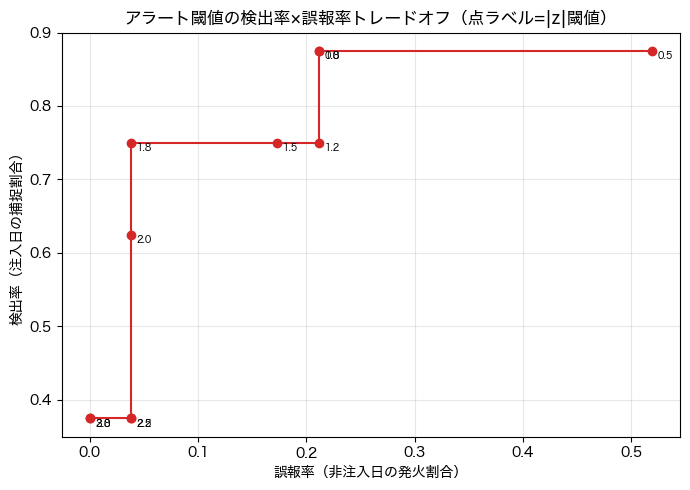

In [9]:
def inject_shocks(z_series, n_shocks=8, size=2.5, seed=0):
    """z 系列にランダム日で ±size のショックを注入し、(注入系列, 注入日マスク) を返します。"""
    rng = np.random.default_rng(seed)
    z = z_series.to_numpy(float).copy()
    idx = rng.choice(len(z), size=n_shocks, replace=False)
    signs = rng.choice([-1.0, 1.0], size=n_shocks)
    z[idx] = z[idx] + size * signs
    mask = np.zeros(len(z), dtype=bool)
    mask[idx] = True
    return pd.Series(z, index=z_series.index), mask


def detection_tradeoff(z_series, mask, thresholds):
    """閾値ごとの (検出率, 誤報率) を返します。"""
    z = z_series.to_numpy(float)
    rows = []
    for thr in thresholds:
        fired = np.abs(z) > thr
        detected = fired[mask].mean() if mask.any() else np.nan
        false_alarm = fired[~mask].mean() if (~mask).any() else np.nan
        rows.append({"閾値|z|": round(float(thr), 2),
                     "検出率": round(float(detected), 3),
                     "誤報率": round(float(false_alarm), 3)})
    return pd.DataFrame(rows)


z_inj, shock_mask = inject_shocks(fly_z_full, n_shocks=8, size=2.5, seed=0)
thr_grid = np.linspace(0.5, 3.0, 11)
tradeoff = detection_tradeoff(z_inj, shock_mask, thr_grid)
print("ショック注入（8日, ±2.5σ）での検出率・誤報率トレードオフ:")
display(tradeoff)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tradeoff["誤報率"], tradeoff["検出率"], marker="o", color="tab:red")
for _, r in tradeoff.iterrows():
    ax.annotate(f"{r['閾値|z|']:.1f}", (r["誤報率"], r["検出率"]), fontsize=7,
                textcoords="offset points", xytext=(4, -6))
ax.set_xlabel("誤報率（非注入日の発火割合）")
ax.set_ylabel("検出率（注入日の捕捉割合）")
ax.set_title("アラート閾値の検出率×誤報率トレードオフ（点ラベル=|z|閾値）")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

閾値を下げるほど左上（高検出・高誤報）へ、上げるほど右下（低検出・低誤報）へ
動きます。運用では「許容できる誤報率」を先に決め、その列の閾値を採用します。
分位点設計は、この誤報率目標を過去分布から閾値へ翻訳する手続きに当たります。

## 実データ適用

60営業日パネルで日次ダッシュボードを再現し、最新営業日の「今朝の画面」を
1枚に組みます。

In [10]:
state = compute_dashboard(panel, asof=None, freq=1, q=0.95)
state["alerts"] = evaluate_alerts(state, q=0.95)

print(f"基準日（as-of）      : {state['asof'].date()}")
print(f"代表ポジション        : {state['hold_maturity']:g}年 年1回利付債 1単位")
print(f"KRD 合計（実効Dur）  : {state['krd'].sum():.3f} 年")
print(f"バタフライ z（当日）  : {state['fly_z_today']:+.2f}")
print(f"アラート件数          : {len(state['alerts'])}")
if state["alerts"]:
    for a in state["alerts"]:
        print(f"  - [{a['panel']}] {a['key']}: {a['value']} / 閾値 {a['threshold']}（{a['note']}）")
else:
    print("  （全指標が過去分位点しきい値の内側）")

基準日（as-of）      : 2026-03-26
代表ポジション        : 10年 年1回利付債 1単位
KRD 合計（実効Dur）  : 8.696 年
バタフライ z（当日）  : -1.49
アラート件数          : 0
  （全指標が過去分位点しきい値の内側）


### 今朝の画面（1枚のダッシュボード）

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


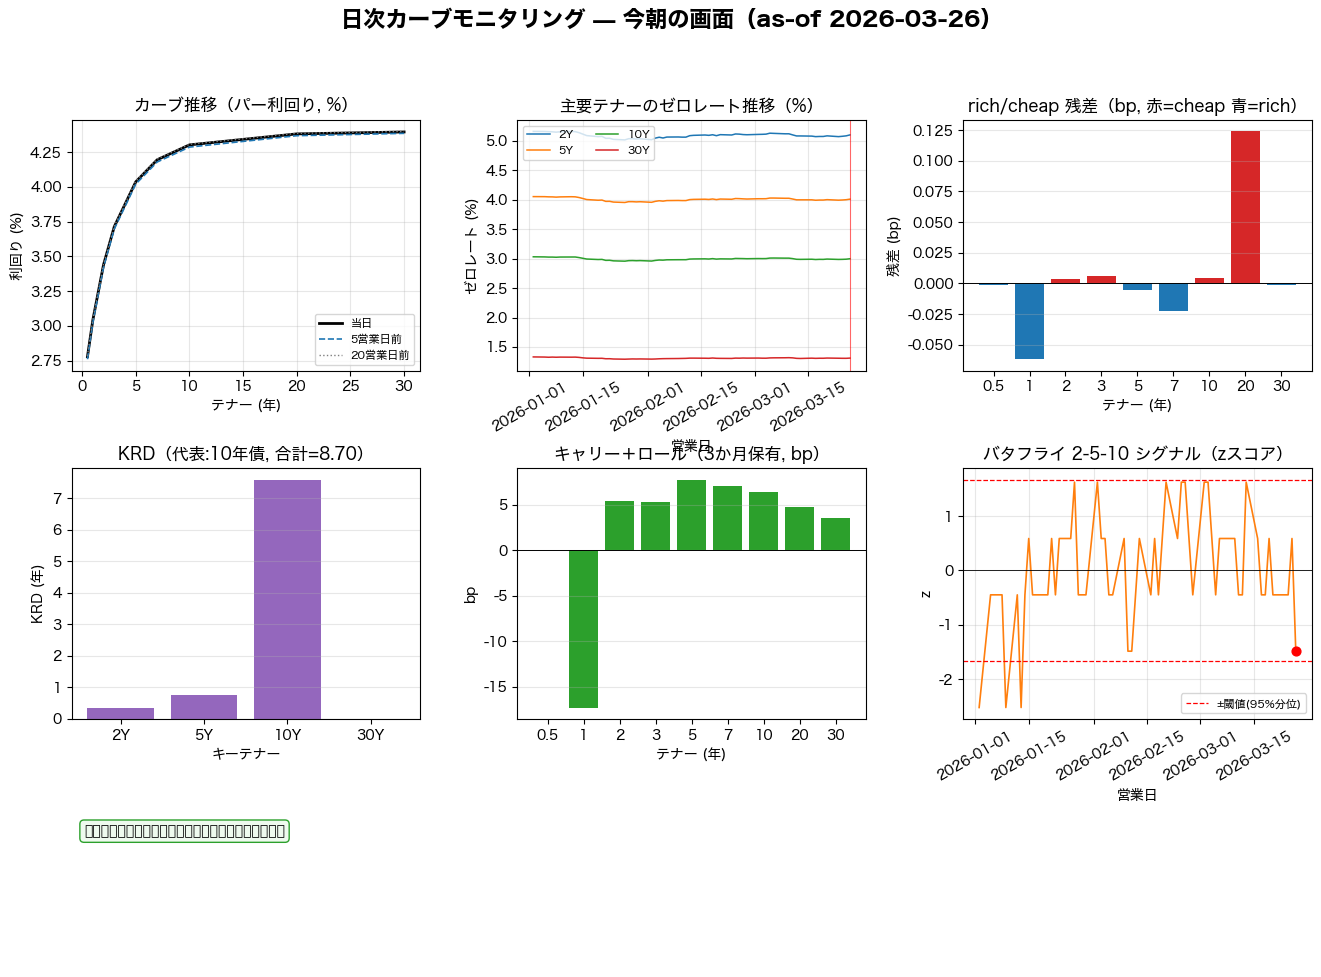

In [11]:
fig = render_dashboard(state)
plt.show()

合成データは滑らかで、rich/cheap 残差は 0.1bp オーダー（実質ゼロ）に収まり、
カーブ変動も小さいため、平常時はアラートがほとんど鳴りません。ここで確認
したいのは水準の市場的意味ではなく、(1) 6パネルが1画面に一覧化されること、
(2) 各指標が過去分布に対する位置（$z$・分位点）で相対化されること、
(3) 閾値超えだけがアラート帯に立つこと、です。実データではベリー・オフザラン
テナーが bp スケールで乖離し、同じ画面がそのまま日々のシグナルになります。

### 過去日への巻き戻し（先読みのない再現）

ダッシュボードは任意の営業日を基準日にできます。20営業日前を基準日にすると、
その日までの履歴だけで閾値と $z$ が作り直されることを確認します。

In [12]:
past_date = panel.index[-20]
state_past = compute_dashboard(panel, asof=past_date, freq=1, q=0.95)
state_past["alerts"] = evaluate_alerts(state_past, q=0.95)
print(f"巻き戻し基準日        : {state_past['asof'].date()}")
print(f"使用した履歴日数      : {len(state_past['panel'])}")
print(f"アラート件数          : {len(state_past['alerts'])}")
assert len(state_past["panel"]) == len(panel.loc[:past_date]), "履歴が先読みしている"
print("先読みなしで過去日を再現できました")

巻き戻し基準日        : 2026-02-27
使用した履歴日数      : 41
アラート件数          : 0
先読みなしで過去日を再現できました


## 演習

1. **アラート閾値と誤報率×検出率のトレードオフ**：本文の `inject_shocks` と
   `detection_tradeoff` を使い、注入ショックの大きさを $1.5\sigma$・$2.5\sigma$・
   $4.0\sigma$ の3通りに変えて、それぞれで検出率×誤報率の曲線を描け。さらに
   「誤報率を 5% 以下に抑える」制約のもとで各ショック規模の最大検出率を表に
   まとめ、閾値を上げる（誤報を嫌う）ほど小さなショックが見逃されることを
   一言で述べよ。
2. **RVトレーダーの発注メモ**：最新営業日の「今朝の画面」から、自分が RV
   トレーダーなら出す注文を1つだけ選べ（例：バタフライのベリー買い／
   特定テナーの rich 売り・cheap 買い）。KRD・キャリー／ロール・rich/cheap・
   バタフライ $z$ のどのパネルを根拠にしたかを明示し、想定保有期間と、
   どの指標がどの水準に戻れば手仕舞うかを3〜5行のメモにせよ。

解答例は `solutions/S11/sol_1103.py` に置きます。

## 用語集

定義の正は `glossary/09_trading.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| モニタリング | monitoring | 市場・ポジション・モデル出力を定時観測し平常からの逸脱を早く捉える継続監視 |
| アラート閾値 | alert threshold | 逸脱を知らせる境界値。過去分布の分位点で決め、誤報率を制御する |
| シグナル | signal | 発注判断の起点となる相対価値の指標（バタフライ $z$、rich/cheap 残差など） |
| 誤報率 | false alarm rate | 本来行動不要なのにアラートが鳴った割合。閾値と検出率のトレードオフにある |